# Environment

In [ ]:
# base
import os
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import scanpy as sc
import squidpy as sq
import cellcharter as cc
import scvi
# import spatialdata as sd
# import spatialdata_plot as sdp
# import spatialdata_io

# data manipulation
import numpy as np
import glasbey
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcdefaults()

# analysis & device specific
%matplotlib inline
CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

import scvi
from lightning.pytorch import seed_everything

seed_everything(12345)
scvi.settings.seed = 12345

INFO: Seed set to 12345
INFO:lightning.fabric.utilities.seed:Seed set to 12345
INFO: Seed set to 12345
INFO:lightning.fabric.utilities.seed:Seed set to 12345


# CellCharter

### Preprocess

/tmp/ipykernel_2585463/2135636810.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs["x"].loc[new_adata.obs_names], adata.obs["y"].loc[new_adata.obs_names] = (


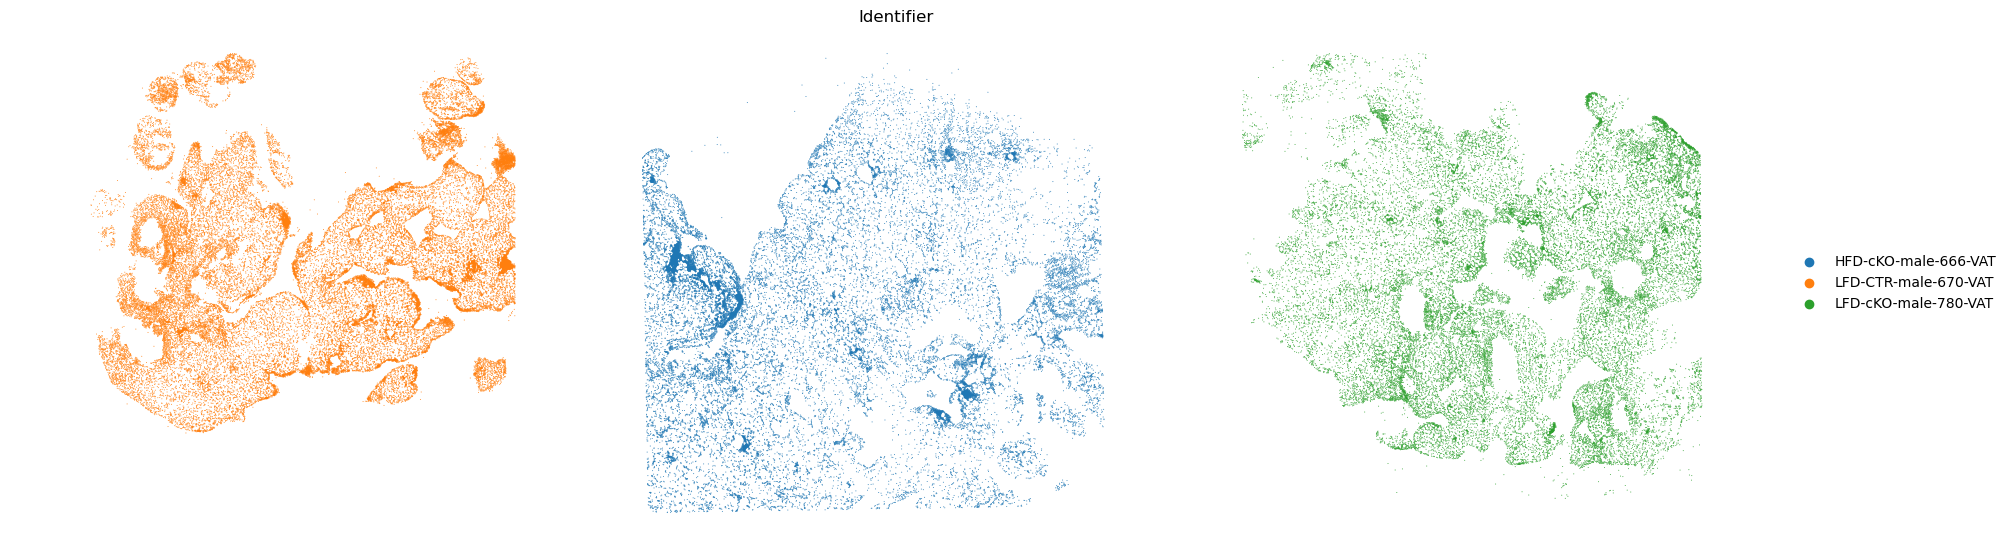

In [3]:
adata = sc.read(
    DATADIR / "processed" / "spatial" / "analysis" / "30_10-clustered.h5ad"
)

adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm["spatial"], 2)

def concat_spatial(x, y, ref_x, ref_y, offset_x=1, offset_y=0, mode="perc"):
    """
    Offsets starting from bottom right corner (Xmax, Ymin).
    Default offset is 1 full width of reference to the right of ref_x.
    """

    if mode == "perc":
        offset_x *= ref_x.max() - ref_x.min()
        offset_y *= ref_y.max() - ref_y.min()

    return x - x.min() + ref_x.max() + offset_x, y - y.min() + ref_y.min() + offset_y

samples = adata.obs["Identifier"].unique()
ref = samples[0]
for n in np.arange(1, len(samples)):
    ref = samples[n - 1]
    samp = samples[n]
    ref_adata = adata[adata.obs["Identifier"] == ref].copy()
    new_adata = adata[adata.obs["Identifier"] == samp].copy()

    adata.obs["x"].loc[new_adata.obs_names], adata.obs["y"].loc[new_adata.obs_names] = (
        concat_spatial(
            new_adata.obs["x"],
            new_adata.obs["y"],
            ref_adata.obs["x"],
            ref_adata.obs["y"],
            offset_x=0.3,
        )
    )

adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

f, ax = plt.subplots(1,1, figsize=(20,6), layout='constrained')
sc.pl.spatial(adata, color="Identifier", spot_size=100, frameon=False, ax=ax)

In [4]:
batch = "Identifier"

# scale by sample
adata.X = adata.layers["counts"].copy().toarray()
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts", 
    batch_key=batch,
)

model = scvi.model.SCVI(adata)
model.train(early_stopping=True, enable_progress_bar=True)
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training:   0%|          | 0/66 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=66` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=66` reached.


### Run Cellcharter

In [7]:
sq.gr.spatial_neighbors(adata, library_key=batch, coord_type='generic', delaunay=True, spatial_key='spatial', percentile=99)
cc.gr.remove_long_links(adata)

In [8]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key=batch)

  0%|          | 0/3 [00:00<?, ?it/s]

In [9]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,10), 
    max_runs=10,
    convergence_tol=0.001
)
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/10


  0%|          | 0/11 [00:00<?, ?it/s]

Iteration 2/10


  0%|          | 0/11 [00:00<?, ?it/s]

Iteration 3/10


...

  0%|          | 0/11 [00:00<?, ?it/s]

Iteration 9/10


  0%|          | 0/11 [00:00<?, ?it/s]

Iteration 10/10


  0%|          | 0/11 [00:00<?, ?it/s]

In [10]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,15), 
    max_runs=10,
    convergence_tol=0.001
)
autok.fit(adata, use_rep='X_cellcharter')

# cc.pl.autok_stability(autok)

Iteration 1/10


  0%|          | 0/16 [00:00<?, ?it/s]

Iteration 2/10


  0%|          | 0/16 [00:00<?, ?it/s]

Iteration 3/10


...

  0%|          | 0/16 [00:00<?, ?it/s]

Iteration 9/10


  0%|          | 0/16 [00:00<?, ?it/s]

Iteration 10/10


  0%|          | 0/16 [00:00<?, ?it/s]

In [11]:
adata.obs['cluster_cellcharter_k3'] = autok.predict(adata, use_rep='X_cellcharter', k=3)
adata.obs['cluster_cellcharter_k6'] = autok.predict(adata, use_rep='X_cellcharter', k=6)
adata.obs['cluster_cellcharter_k10'] = autok.predict(adata, use_rep='X_cellcharter', k=10)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU avai

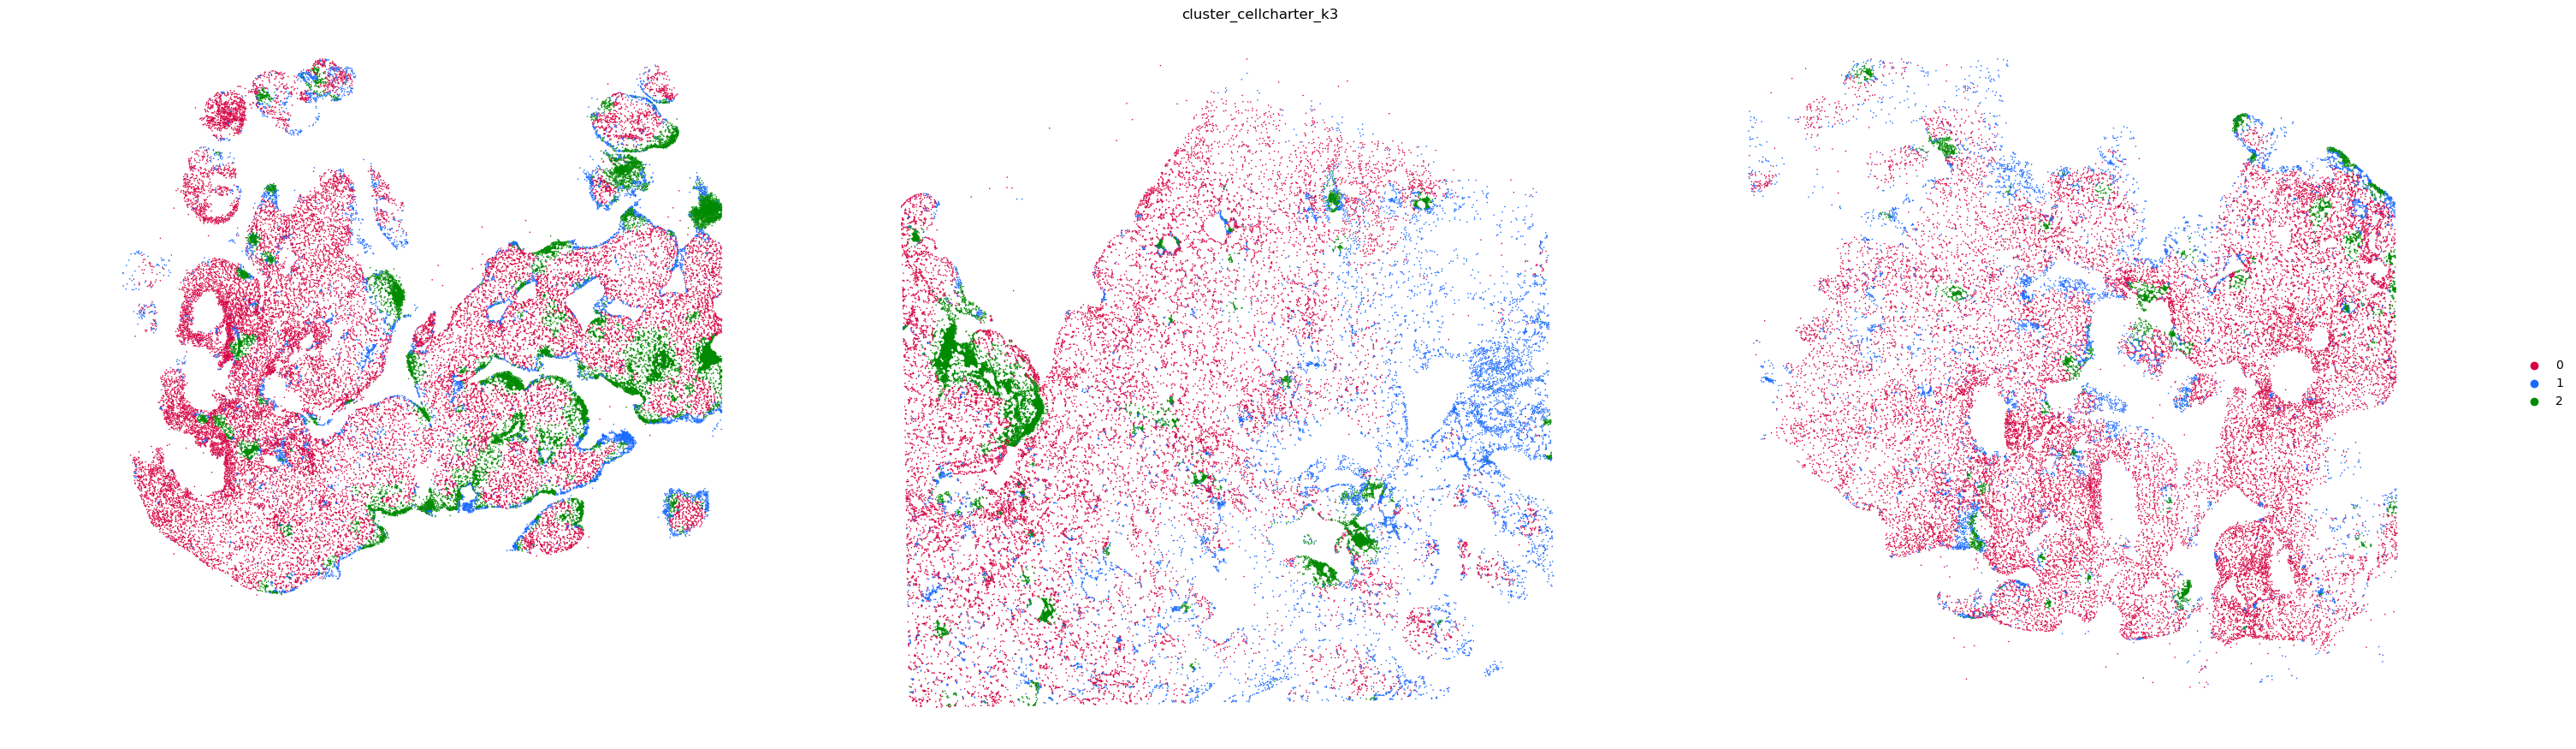

In [12]:
cluster = "cluster_cellcharter_k3"

f, ax = plt.subplots(1,1, figsize=(30,9), layout='constrained')
sc.pl.spatial(
    adata, 
    color=cluster, 
    spot_size=100,
    frameon=False,
    ax=ax,
    palette=glasbey.create_palette(len(adata.obs[cluster].cat.categories))
)

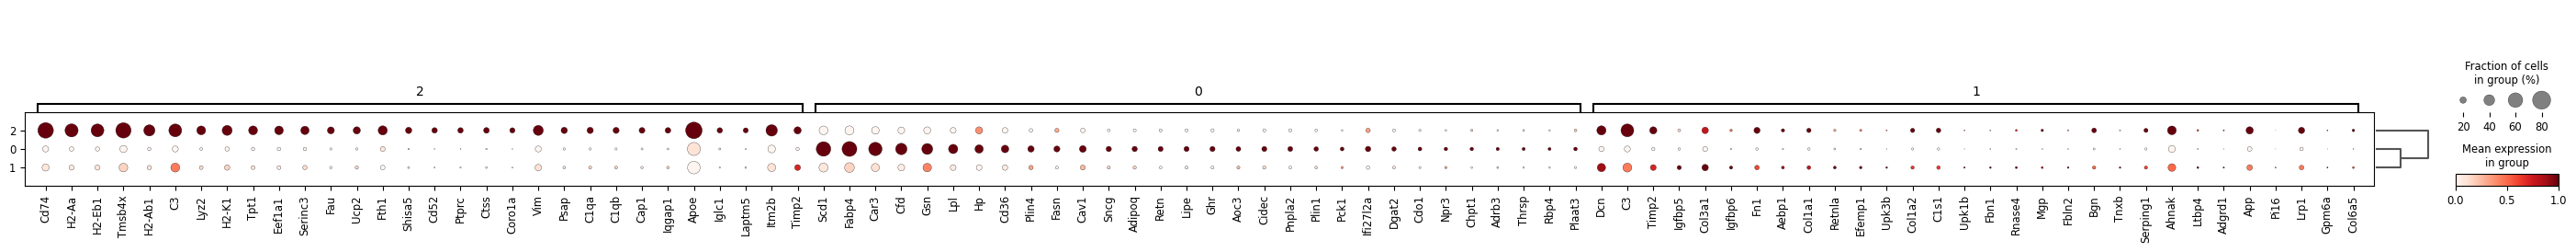

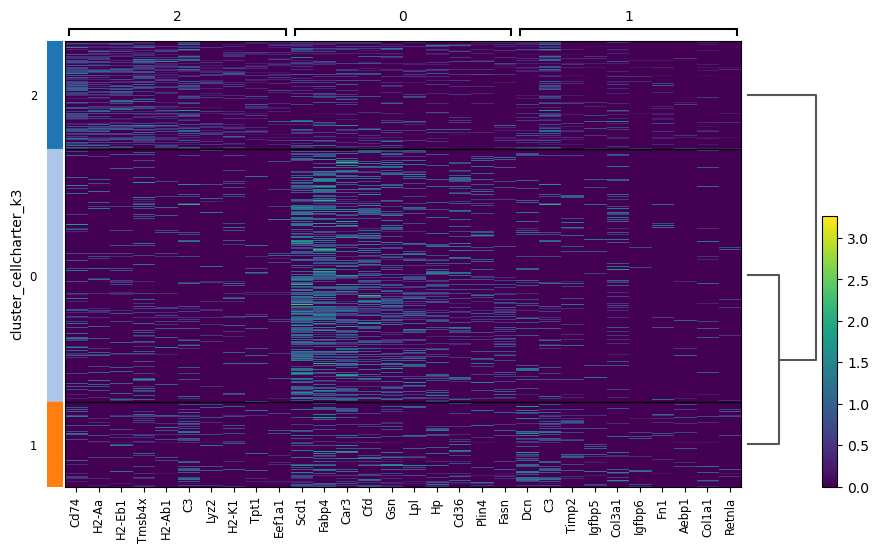

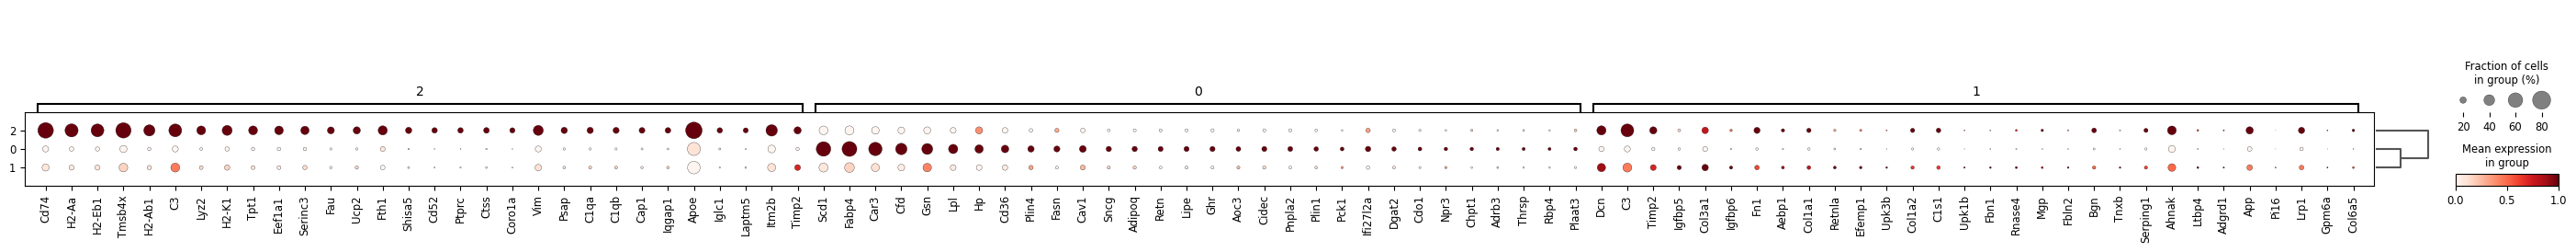

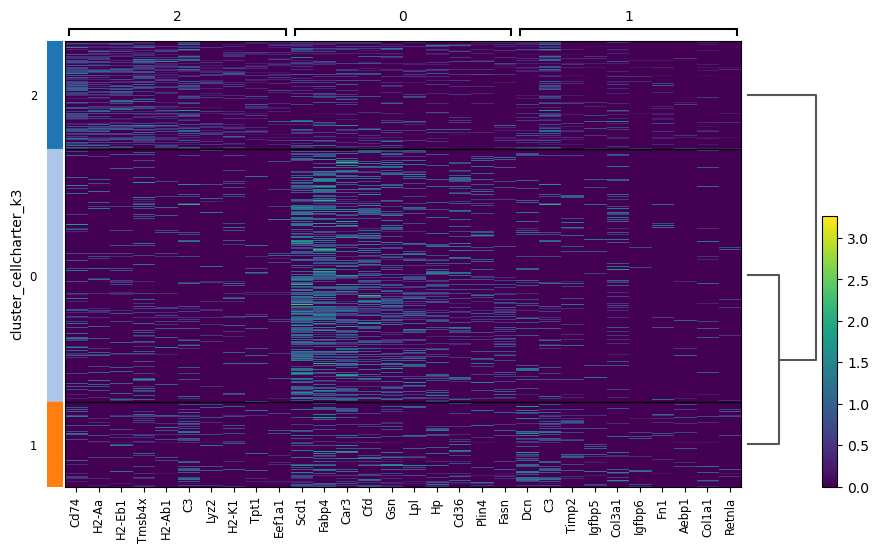

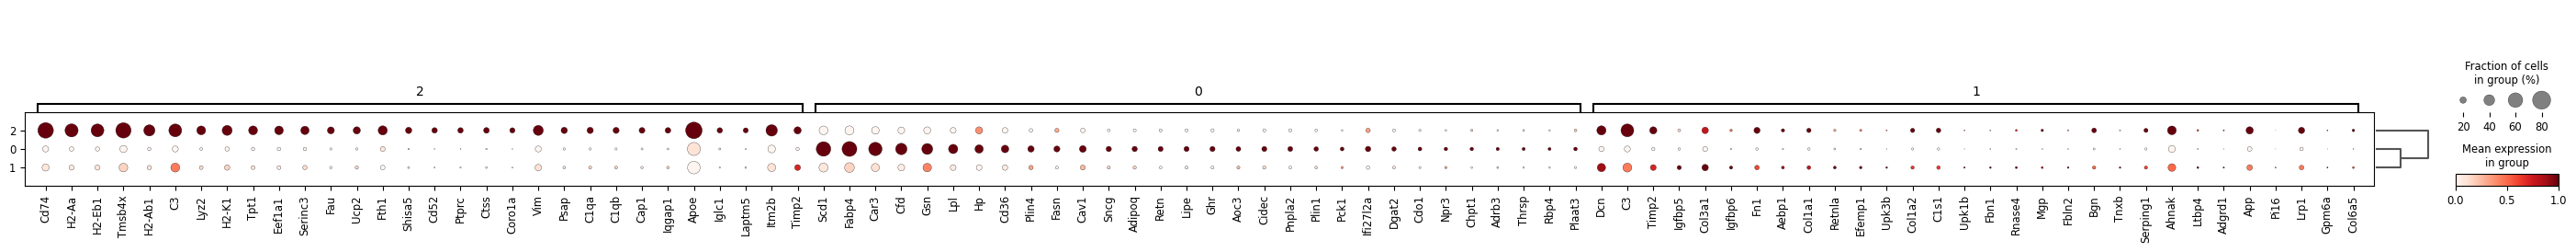

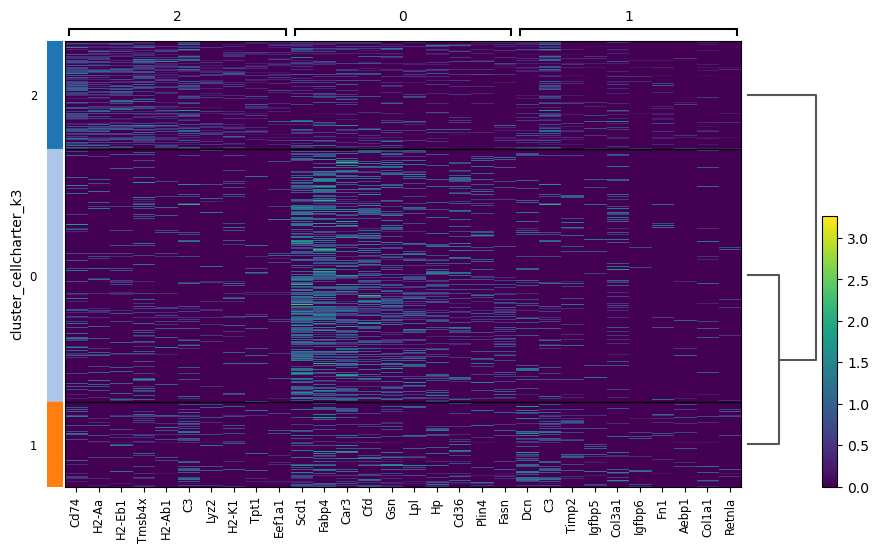

In [ ]:
ks = [3,6,10]
cluster = "cluster_cellcharter"
de_key = "DEGs"
runDEGs = True

for k in ks:
    if runDEGs is True:
        sc.tl.rank_genes_groups(
            adata,
            groupby=cluster,
            key_added=f"{de_key}_k{k}",
            use_raw=False,
            layer="normalized",
            method="wilcoxon",
        )

    sc.pl.rank_genes_groups_dotplot(
        adata,
        groupby=cluster,
        key=f"{de_key}_{k}",
        standard_scale="var",
        n_genes=30,
        # min_logfoldchange=2,
        # ax=ax,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata, key=f"{de_key}_{k}", groupby=[cluster], layer="normalized"
    )

In [14]:
adata.write(DATADIR / "processed" / "spatial" / "analysis" / "30_10-clustered-cellcharter.h5ad")

In [15]:
adata = sc.read_h5ad(DATADIR / "processed" / "spatial" / "analysis" / "30_10-clustered-cellcharter.h5ad")